# SPOmiAlign Demo: Image to Image Section Alignment

This notebook follows a fixed workflow:
1. Input unaligned slices (paired images)
2. Imaging (generation of spatial structural images, SSI)
3. Sections matching and warpping
4. Reassignment
5. Output aligned slices


## 1. Input unaligned slices (paired images)

In [1]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np



NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents)
    if (candidate / "SPOmiAlign").is_dir()
)
DEMO_DIR = PROJECT_ROOT / "demo"
sys.path.append(str(PROJECT_ROOT / "SPOmiAlign"))

from roma import align_and_process_images
from data_preprocessing import scatter_h5ad_to_image

DATA_DIR = Path(
    os.environ.get("SPOMIALIGN_DEMO_DATA_DIR", DEMO_DIR / "SPOmiAlign_Repro")
).expanduser()
SAVE_DIR = Path(
    os.environ.get("SPOMIALIGN_DEMO_SAVE_DIR", DEMO_DIR / "output")
).expanduser()
SAVE_PATH = SAVE_DIR / "h5ad_2_img/PUCK43"
SAVE_PATH.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {SAVE_PATH}")
h5ad_path = DATA_DIR / "data_preprocessing" / "Puck_Num_43.h5ad"
target_image_path = DATA_DIR / "output_reference" / "CCF_100048576_273.png"
niss_image_path = DATA_DIR / "output_niss" / "niss_40.png"

assert h5ad_path.exists(), f"H5AD file not found: {h5ad_path}"
assert target_image_path.exists(), f"CCF target image not found: {target_image_path}"
assert niss_image_path.exists(), f"Nissl image not found: {niss_image_path}"

target_img_for_shape = cv2.imread(str(target_image_path), cv2.IMREAD_COLOR)
niss_img_for_shape = cv2.imread(str(niss_image_path), cv2.IMREAD_COLOR)
assert target_img_for_shape is not None, f"Failed to read CCF target image: {target_image_path}"
assert niss_img_for_shape is not None, f"Failed to read Nissl image: {niss_image_path}"
target_h, target_w = target_img_for_shape.shape[:2]
niss_h, niss_w = niss_img_for_shape.shape[:2]

print(f"Input H5AD: {h5ad_path}")
print(f"Nissl image: {niss_image_path}")
print(f"CCF target image: {target_image_path}")
print(f"Nissl size: {niss_w} x {niss_h}")
print(f"CCF size: {target_w} x {target_h}")


Data directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro
Output directory: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43
Input H5AD: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/data_preprocessing/Puck_Num_43.h5ad
Nissl image: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_niss/niss_40.png
CCF target image: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/SPOmiAlign_Repro/output_reference/CCF_100048576_273.png
Nissl size: 5023 x 3413
CCF size: 5023 x 3594


## 2. Imaging (generation of spatial structural images, SSI)

[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/Gen_img_PUCK43_scatter.png (4405x5021, background=black, shape=circle, points=41783)


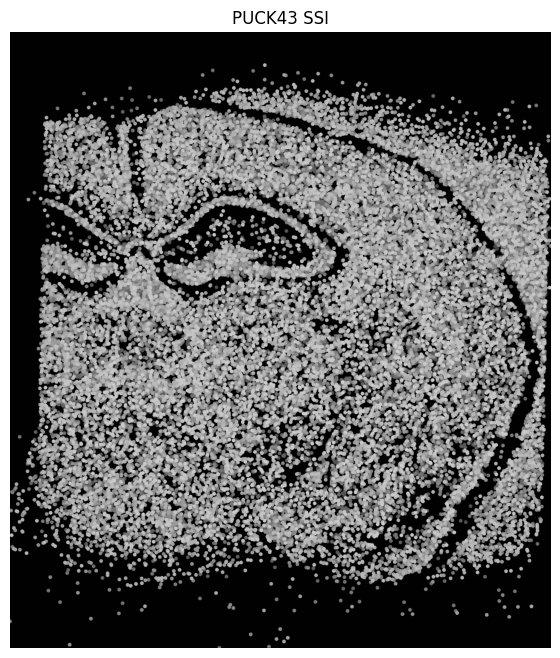

In [2]:
%matplotlib inline
Gen_img_path = SAVE_PATH / "Gen_img_PUCK43_scatter.png"

# Keep rasterize-style coordinate handling for the initial SSI.
_, origin = scatter_h5ad_to_image(
    input_h5ad=str(h5ad_path),
    output_png=str(Gen_img_path),
    x_obs_col="Raw_Slideseq_X",
    y_obs_col="Raw_Slideseq_Y",
    intensity_mode="obs_col",
    intensity_obs_col="nFeature_Spatial",
    intensity_log_transform=True,
    threshold_percentile=80,
    background="black",
    point_shape="circle",
    radius=5,
    rotate=90,
    scale=1.0,
    display_long_side=0,
    padding=0,
    dpi=200,
    marker_alpha=1.0,
    gray_min=0.55,
    gray_max=1.0,
    invert_intensity=False,
    enhance=True,
)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(cv2.imread(str(Gen_img_path)), cv2.COLOR_BGR2RGB))
plt.title("PUCK43 SSI")
plt.axis("off")
plt.show()


## 3. Sections matching and warpping

Using device: cuda:0


2026-04-13 00:13:45.652 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 1152)


Running RoMa matching...
Estimating affine+bspline transform...
Warping images...
Padding fill color: (255, 255, 255)
Processing H5AD coordinates...
Raw_Slideseq_X Raw_Slideseq_Y
[OK] Step 00 source coordinates mapped to render space: 204741/209220 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_niss/debug_step_00_source_in_render_space.png
🔄 Applying manual pre-transform: rotate=90.0°, scale=1.0
[OK] Step 01 after manual pre-transform (source canvas): 209100/209220 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_niss/debug_step_01_after_manual_pretransform.png
[OK] Step 02 after resize to registration grid (source resized canvas): 209099/209220 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_niss/debug_step_02_after_resize_to_registration.png
[OK] Step 03 after registration t

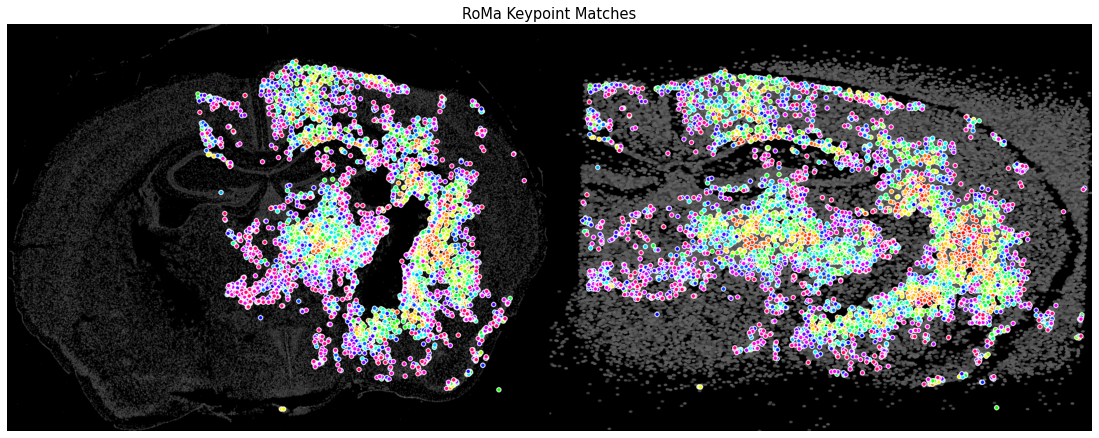

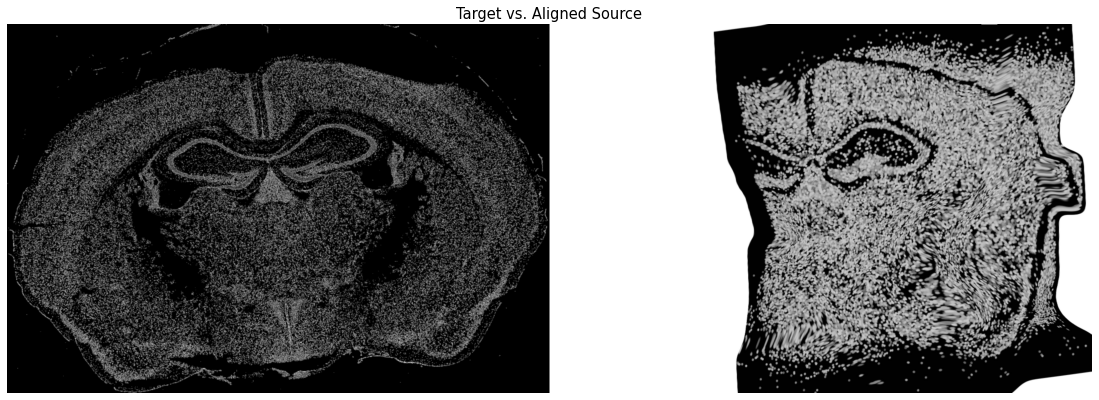

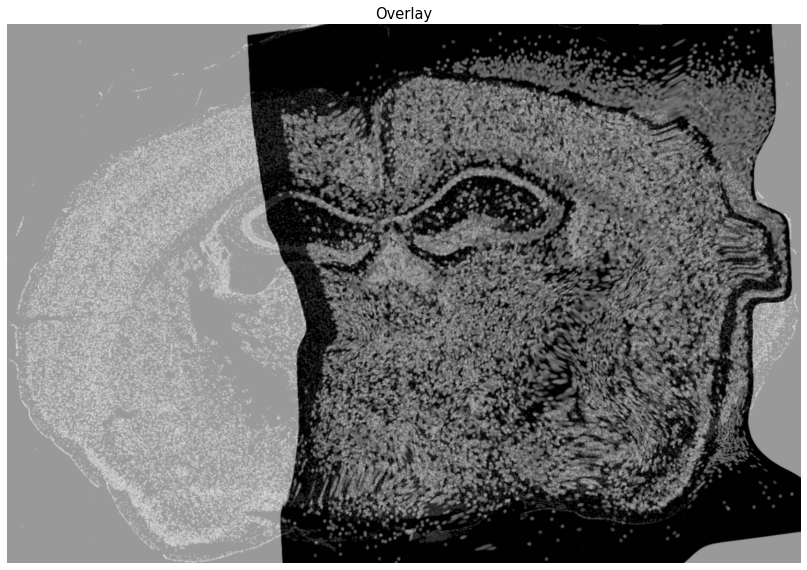

Alignment runtime: 21.0789 seconds
Done. Results saved to /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_niss
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_niss/transformed_h5ad_scatter.png (5023x3413, background=black, shape=circle, points=41783)
Using device: cuda:0


2026-04-13 00:14:28.573 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 1152)


Running RoMa matching...
Estimating affine+bspline transform...
Warping images...
Padding fill color: (255, 255, 255)
Processing H5AD coordinates...
Raw_Slideseq_X Raw_Slideseq_Y
[OK] Step 00 source coordinates mapped to render space: 208984/209220 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_ccf/debug_step_00_source_in_render_space.png
[OK] Step 02 after resize to registration grid (source resized canvas): 208981/209220 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_ccf/debug_step_02_after_resize_to_registration.png
[OK] Step 03 after registration transform (target resized canvas): 206938/209220 points inside canvas -> /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_ccf/debug_step_03_after_registration_transform.png
[OK] Step 04 after rescale back (target original canvas): 206971/209220 points i

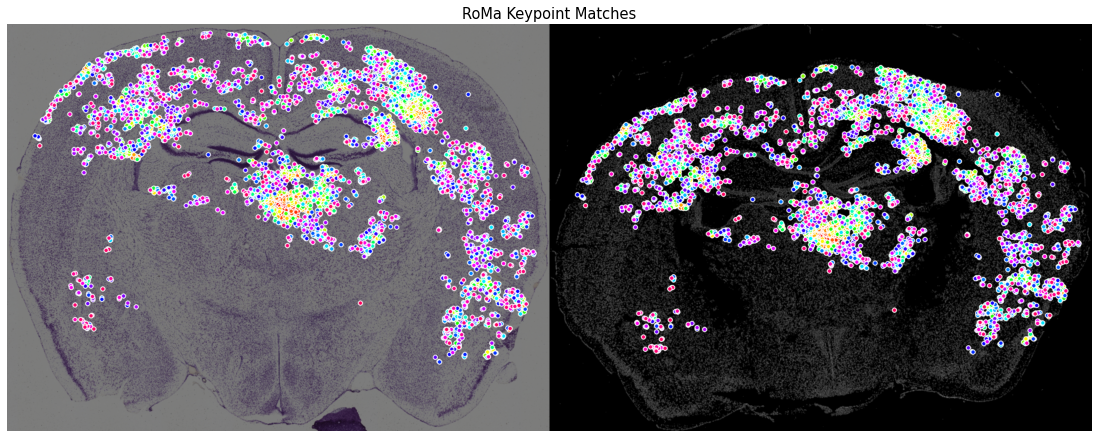

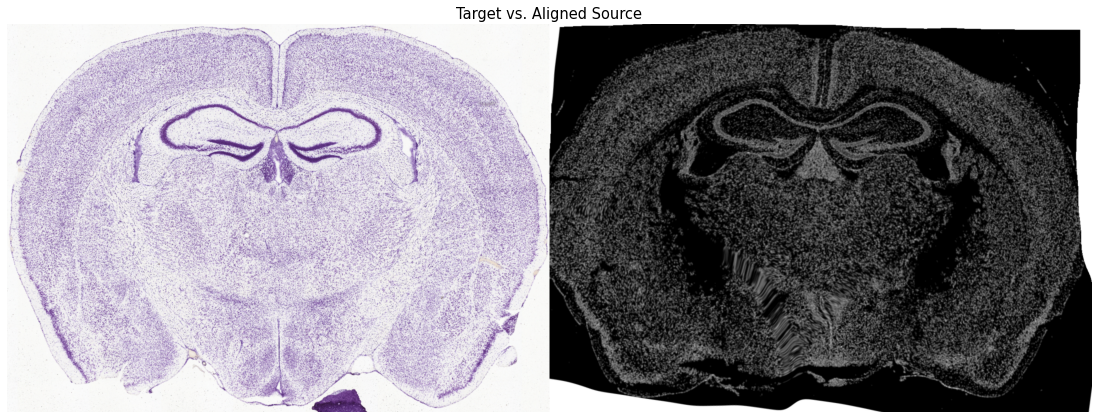

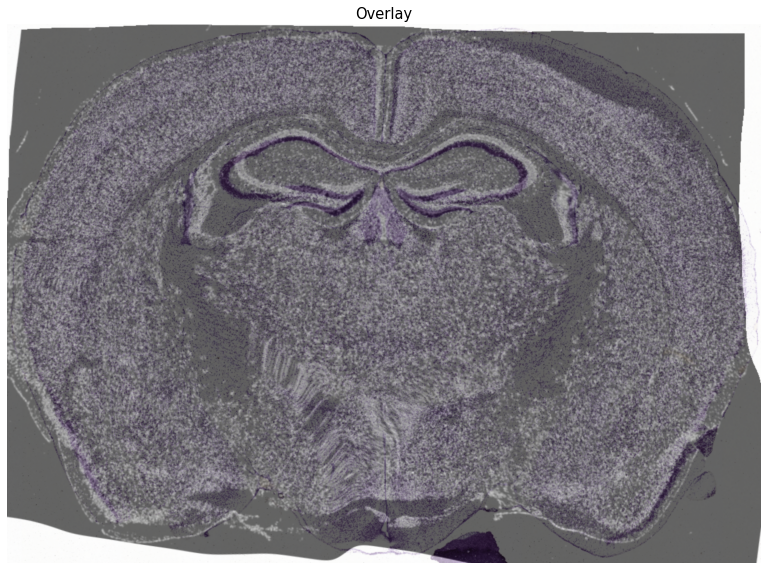

Alignment runtime: 18.1055 seconds
Done. Results saved to /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_ccf
[OK] Scatter PNG saved: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_ccf/transformed_h5ad_scatter.png (5023x3594, background=black, shape=circle, points=41783)


('/storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_ccf/transformed_h5ad_scatter.png',
 None)

In [3]:
save_path_alignment_with_niss = SAVE_PATH / "alignment_with_niss"
save_path_alignment_with_niss.mkdir(parents=True, exist_ok=True)
transformed_with_niss_h5ad_path = save_path_alignment_with_niss / "transformed.h5ad"
transformed_with_niss_h5ad_img_path = save_path_alignment_with_niss / "transformed_h5ad_scatter.png"

align_and_process_images(
    img1_path=str(niss_image_path),
    img2_path=str(Gen_img_path),
    h5ad_path=str(h5ad_path),
    method="affine+bspline",
    output_dir=str(save_path_alignment_with_niss),
    x_obs_col="Raw_Slideseq_X",
    y_obs_col="Raw_Slideseq_Y",
    rotate=90.0,
    scale=1.0,
    origin=origin,
    auto_upscale_reference=False,
)

# Render transformed PUCK43 directly in the Nissl canvas.
scatter_h5ad_to_image(
    input_h5ad=str(transformed_with_niss_h5ad_path),
    output_png=str(transformed_with_niss_h5ad_img_path),
    x_obs_col="Raw_Slideseq_X",
    y_obs_col="Raw_Slideseq_Y",
    intensity_mode="obs_col",
    intensity_obs_col="nFeature_Spatial",
    intensity_log_transform=True,
    threshold_percentile=80,
    background="black",
    point_shape="circle",
    radius=5,
    rotate=0.0,
    scale=1.0,
    display_long_side=0,
    padding=0,
    canvas_size=(niss_w, niss_h),
    dpi=120,
    marker_alpha=1.0,
    gray_min=0.55,
    gray_max=1.0,
    invert_intensity=False,
    enhance=True,
)

save_path_alignment_with_ccf = SAVE_PATH / "alignment_with_ccf"
save_path_alignment_with_ccf.mkdir(parents=True, exist_ok=True)
transformed_with_ccf_h5ad_path = save_path_alignment_with_ccf / "transformed.h5ad"
transformed_with_ccf_h5ad_img_path = save_path_alignment_with_ccf / "transformed_h5ad_scatter.png"

align_and_process_images(
    img1_path=str(target_image_path),
    img2_path=str(niss_image_path),
    h5ad_path=str(transformed_with_niss_h5ad_path),
    method="affine+bspline",
    output_dir=str(save_path_alignment_with_ccf),
    x_obs_col="Raw_Slideseq_X",
    y_obs_col="Raw_Slideseq_Y",
    rotate=0.0,
    scale=1.0,
    origin=origin,
    auto_upscale_reference=False,
)

# Render transformed PUCK43 directly in the CCF canvas.
scatter_h5ad_to_image(
    input_h5ad=str(transformed_with_ccf_h5ad_path),
    output_png=str(transformed_with_ccf_h5ad_img_path),
    x_obs_col="Raw_Slideseq_X",
    y_obs_col="Raw_Slideseq_Y",
    intensity_mode="obs_col",
    intensity_obs_col="nFeature_Spatial",
    intensity_log_transform=True,
    threshold_percentile=80,
    background="black",
    point_shape="circle",
    radius=5,
    rotate=0.0,
    scale=1.0,
    display_long_side=0,
    padding=0,
    canvas_size=(target_w, target_h),
    dpi=200,
    marker_alpha=1.0,
    gray_min=0.55,
    gray_max=1.0,
    invert_intensity=False,
    enhance=True,
)


## 4. Reassignment

No reassignment step is used in this PUCK43 image-alignment demo.

## 5. Output aligned slices

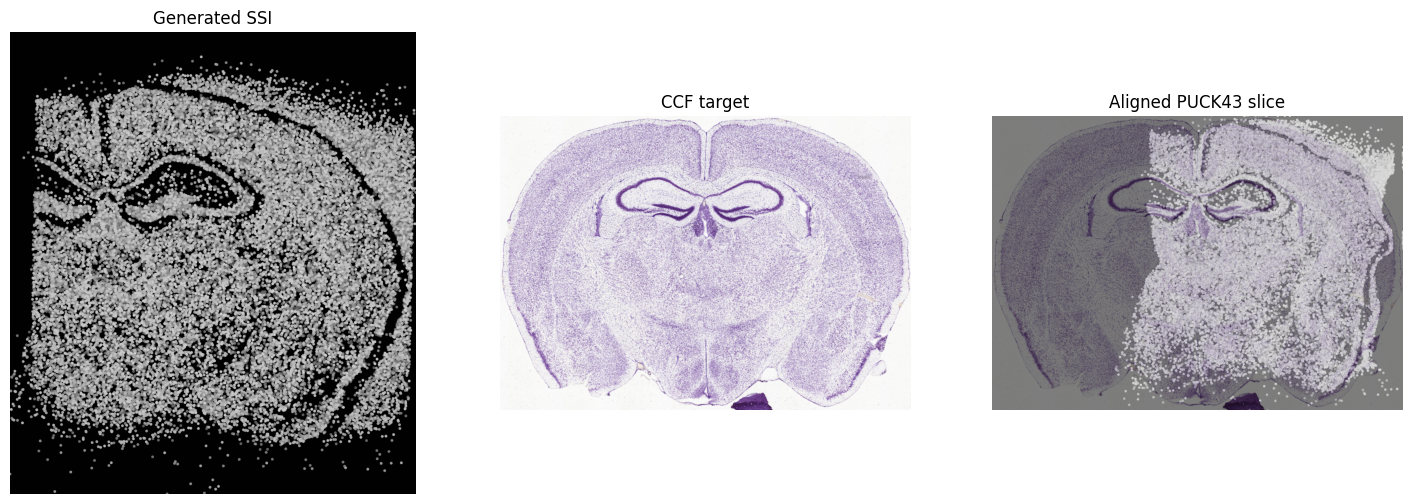

Aligned H5AD after Nissl and CCF matching: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_ccf/transformed.h5ad
Overlay image: /storage/hermes/yiwang/spomialign/SPOmiAlign-main/demo/output/h5ad_2_img/PUCK43/alignment_with_ccf/color_alignment_overlay.png


In [4]:
target_img = cv2.imread(str(target_image_path))
aligned_gray = cv2.imread(str(transformed_with_ccf_h5ad_img_path), cv2.IMREAD_GRAYSCALE)
assert target_img is not None, f"Failed to read target image: {target_image_path}"
assert aligned_gray is not None, f"Failed to read transformed SSI image: {transformed_with_ccf_h5ad_img_path}"

h5ad_mask_full = np.zeros(target_img.shape[:2], dtype=np.uint8)
h_limit = min(h5ad_mask_full.shape[0], aligned_gray.shape[0])
w_limit = min(h5ad_mask_full.shape[1], aligned_gray.shape[1])
h5ad_mask_full[:h_limit, :w_limit] = aligned_gray[:h_limit, :w_limit]

aligned_bgr = cv2.cvtColor(h5ad_mask_full, cv2.COLOR_GRAY2BGR)
overlay_img = cv2.addWeighted(target_img, 0.5, aligned_bgr, 0.5, 0)
overlay_save_path = save_path_alignment_with_ccf / "color_alignment_overlay.png"
cv2.imwrite(str(overlay_save_path), overlay_img)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(cv2.imread(str(Gen_img_path)), cv2.COLOR_BGR2RGB))
axes[0].set_title("Generated SSI")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("CCF target")
axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
axes[2].set_title("Aligned PUCK43 slice")
axes[2].axis("off")
plt.show()

print(f"Aligned H5AD after Nissl and CCF matching: {transformed_with_ccf_h5ad_path}")
print(f"Overlay image: {overlay_save_path}")
